# Example 1: Calm Water Resistance Using Speed-Power Curve

## Overview

This notebook demonstrates:
1. Creating a calm water resistance model from speed-power data points
2. Interpolating power for any given speed
3. Interpolating speed for any given power
4. Visualizing the speed-power relationship 

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ship_model_lib.calm_water_resistance import CalmWaterResistanceBySpeedPowerCurve

## Define Reference Data

Reference speed-power points typically come from:
- Sea trials
- Model basin tests
- CFD simulations

The relationship between speed and power typically follows a cubic relationship for ships.

In [2]:
# Define reference speed-power points
speed_kn = np.array([2, 4, 6, 8, 10, 12, 14])
power_kw = np.power(speed_kn, 3) * 5  # Cubic relationship (typical for ships)

print("Reference Data Points:")
print(f"Speeds (kn):  {speed_kn}")
print(f"Powers (kW):  {power_kw}")

Reference Data Points:
Speeds (kn):  [ 2  4  6  8 10 12 14]
Powers (kW):  [   40   320  1080  2560  5000  8640 13720]


## Create Resistance Model

The `CalmWaterResistanceBySpeedPowerCurve` class creates an interpolation model from the reference data.

In [3]:
resistance_model = CalmWaterResistanceBySpeedPowerCurve(
    speed_ref_kn=speed_kn,
    power_ref_kw=power_kw
)

print("✓ Resistance model created successfully")

✓ Resistance model created successfully


## Example 1: Interpolate Power from Speed

Get the required power for specific ship speeds.

In [4]:
test_speeds = np.array([3, 5, 7, 9, 11, 13])

print("Power Interpolation Results:")
print(f"{'Speed (kn)':>12} | {'Power (kW)':>12} | {'Extrapolated':>13}")
print("-" * 42)

for speed in test_speeds:
    power_result = resistance_model.get_power_from_speed(speed_kn=speed)
    print(f"{speed:>12.2f} | {power_result.value:>12.2f} | {str(power_result.is_extrapolated):>13}")

Power Interpolation Results:
  Speed (kn) |   Power (kW) |  Extrapolated
------------------------------------------
        3.00 |       135.00 |         False
        5.00 |       625.00 |         False
        7.00 |      1715.00 |         False
        9.00 |      3645.00 |         False
       11.00 |      6655.00 |         False
       13.00 |     10985.00 |         False


## Example 2: Interpolate Speed from Power

Get the ship speed for specific power outputs (inverse interpolation).

In [5]:
test_powers = np.array([100, 500, 1000, 2000, 5000])

print("Speed Interpolation Results:")
print(f"{'Power (kW)':>12} | {'Speed (kn)':>12} | {'Extrapolated':>13}")
print("-" * 42)

for power in test_powers:
    speed_result = resistance_model.get_speed_from_power(power_kw=power)
    print(f"{power:>12.2f} | {speed_result.value:>12.2f} | {str(speed_result.is_extrapolated):>13}")

Speed Interpolation Results:
  Power (kW) |   Speed (kn) |  Extrapolated
------------------------------------------
      100.00 |         2.71 |         False
      500.00 |         4.64 |         False
     1000.00 |         5.85 |         False
     2000.00 |         7.37 |         False
     5000.00 |        10.00 |         False


## Visualization

Create smooth curves showing both forward and inverse interpolation.


Visualization saved as 'example_01_speed_power_curve.png'


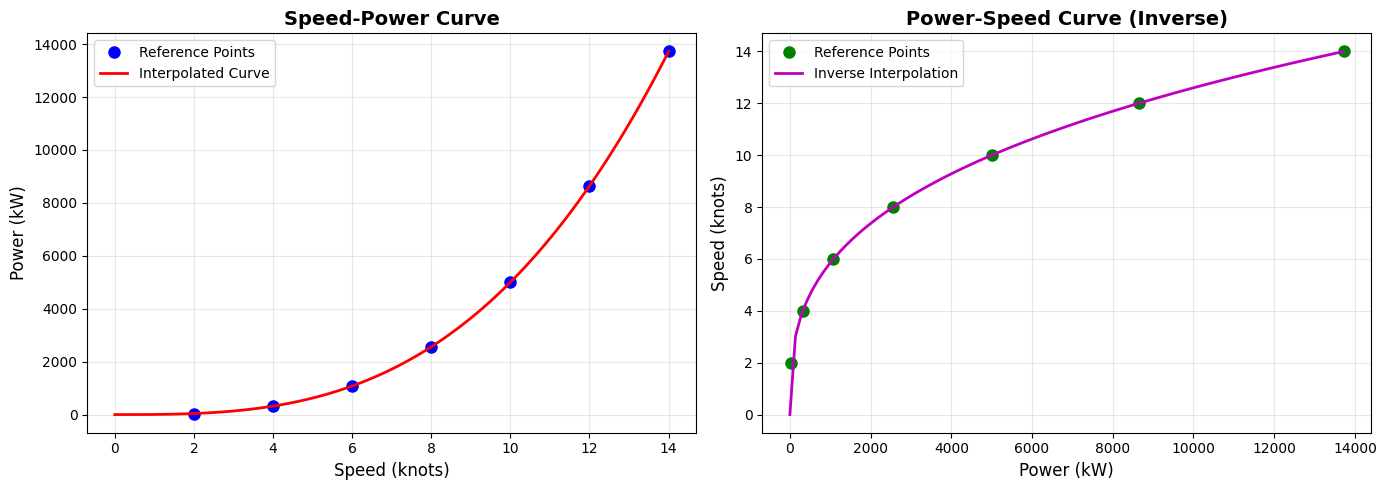

In [6]:
# Generate smooth curves
speed_smooth = np.linspace(0, speed_kn.max(), 100)
power_smooth = resistance_model.get_power_from_speed(speed_kn=speed_smooth)

power_range = np.linspace(0, power_kw.max(), 100)
speed_from_power = resistance_model.get_speed_from_power(power_kw=power_range)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Speed vs Power
ax1.plot(speed_kn, power_kw, 'bo', markersize=8, label='Reference Points')
ax1.plot(speed_smooth, power_smooth.value, 'r-', linewidth=2, label='Interpolated Curve')
ax1.set_xlabel('Speed (knots)', fontsize=12)
ax1.set_ylabel('Power (kW)', fontsize=12)
ax1.set_title('Speed-Power Curve', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: Power vs Speed (inverse interpolation)
ax2.plot(power_kw, speed_kn, 'go', markersize=8, label='Reference Points')
ax2.plot(power_range, speed_from_power.value, 'm-', linewidth=2, label='Inverse Interpolation')
ax2.set_xlabel('Power (kW)', fontsize=12)
ax2.set_ylabel('Speed (knots)', fontsize=12)
ax2.set_title('Power-Speed Curve (Inverse)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('example_01_speed_power_curve.png', dpi=150, bbox_inches='tight')
print("\nVisualization saved as 'example_01_speed_power_curve.png'")
plt.show()

## Summary

This example demonstrated:
- ✓ Creating a resistance model from speed-power data
- ✓ Forward interpolation (speed → power)
- ✓ Inverse interpolation (power → speed)
- ✓ Visualization of interpolation curves

**Key Observations:**
- Power increases cubically with speed (typical for ship resistance)
- Both forward and inverse interpolation work smoothly within the data range
- The model can extrapolate beyond the reference data but with reduced accuracy